# Perancangan dan Implementasi FIR High-Pass Filter

Notebook ini melakukan perancangan dan penerapan filter FIR High-Pass untuk sinyal EMG (Tibialis Anterior).

Metode yang digunakan:
- Koefisien dihitung manual menggunakan Window Method.
- Evaluasi pada domain waktu dan frekuensi.

### Identitas Kelompok

**Kelompok 1**

| Nama | NIM |
|--------|--------|
| Aulia Primaswara | 163231044 |
| Alexander Kynan K | 163231039 |

**Objek Sinyal :**

Sinyal EMG otot **Tibialis Anterior** yang diperoleh dari proses akuisisi
sinyal biomedis.

### 1. Inisialisasi Library

Tahap ini digunakan untuk memanggil library yang diperlukan dalam proses
pengolahan sinyal, perancangan filter, analisis frekuensi, serta visualisasi
hasil.

In [15]:
# Import library yang diperlukan
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt
import matplotlib as mlp

mlp.rcParams['figure.figsize'] = (15,4)
mlp.rcParams['font.size'] = 16

### 2. Spesifikasi Filter

Filter yang dirancang merupakan FIR High-Pass menggunakan Window Method (Hamming Window) dengan karakteristik sebagai berikut:

- Frekuensi sampling (Fs) = 1000 Hz
- Frekuensi cut-off (Fc) = 20 Hz
- Order = 100

Pemilihan frekuensi cut-off 20 Hz bertujuan untuk mengurangi komponen
frekuensi rendah yang umumnya berasal dari baseline drift, gerakan elektroda,
dan noise gerakan otot tanpa menghilangkan informasi utama sinyal EMG.

In [16]:
# Spesifikasi filter
Fs = 1000        # Frekuensi sampling (Hz)
Fc = 20          # Frekuensi cut-off (Hz)
numtaps = 167    # Jumlah koefisien (harus ganjil untuk simetri linier fase)
window_type = 'hamming'       # Jenis window
order = numtaps - 1           # Order FIR

print(f"Fs = {Fs} Hz")
print(f"Fc = {Fc} Hz")
print(f"Order = {order}")
print(f"Numtaps = {numtaps}")
print(f"Window = {window_type}")

Fs = 1000 Hz
Fc = 20 Hz
Order = 166
Numtaps = 167
Window = hamming


### 3. Akuisisi Data dan Visualisasi Sinyal Asli

Data sinyal EMG dibaca dari berkas CSV dan divisualisasikan pada domain
waktu untuk mengamati karakteristik amplitudo sinyal sebelum dilakukan
proses filtering.

Jumlah sampel = 6434


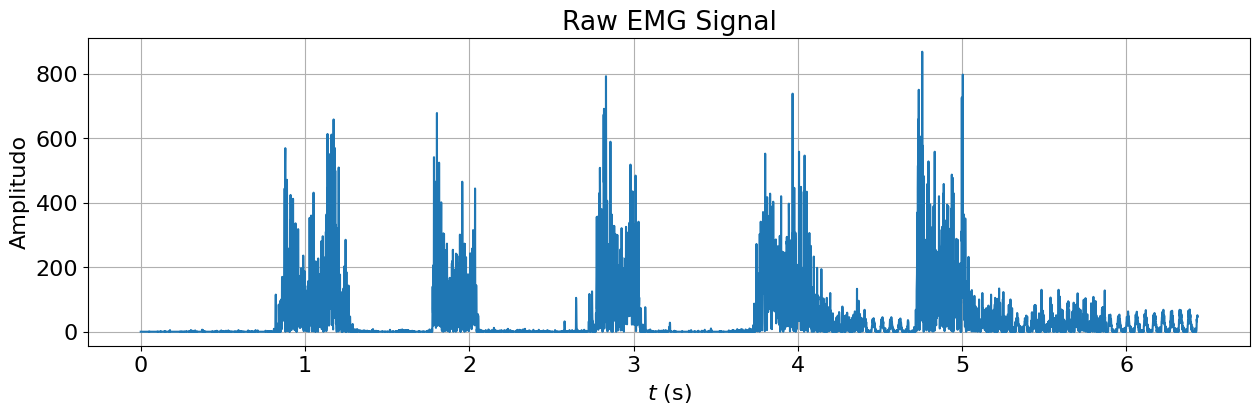

In [17]:
# Membaca data EMG (sesuaikan nama file jika perlu)
df = pd.read_csv('d:/project/UA/code/damn psll/Data_EMG/emg_data (11).csv')
y = df['EMG'].values
t = np.arange(len(y)) / Fs
print('Jumlah sampel =', len(y))
# Plot sinyal asli
plt.figure()
plt.plot(t, y)
plt.title('Raw EMG Signal')
plt.xlabel('$t$ (s)')
plt.ylabel('Amplitudo')
plt.grid()
plt.show()

### 4. Analisis Spektrum Frekuensi Sinyal Asli

Untuk mengetahui distribusi energi sinyal terhadap frekuensi, dilakukan
Transformasi Fourier Diskrit (FFT). Hasil spektrum digunakan sebagai acuan
dalam menentukan efektivitas filter yang dirancang.

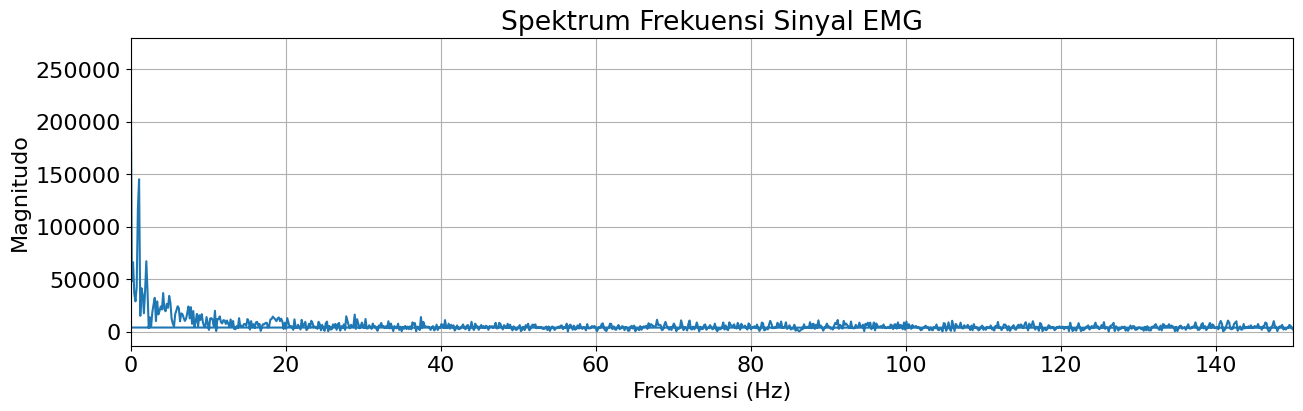

In [18]:
# spektrum sinyal asli
yhat = np.fft.fft(y)

fcycles = np.fft.fftfreq(
    len(y),
    d=1/Fs
)

plt.figure()
plt.plot(fcycles,np.abs(yhat))
plt.xlim([0,150])
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitudo")
plt.title("Spektrum Frekuensi Sinyal EMG")
plt.grid()
plt.show()

### 4. Desain Koefisien FIR High-Pass Manual

Metode yang digunakan: **Window Method**

Langkah-langkahnya:
1. **Buat window function** (e.g., Hamming window): $$w[n] = 0.54 - 0.46\cos\left(\frac{2\pi n}{N-1}\right)$$
2. **Hitung ideal low-pass impulse response**: $$h_{lp}[n] = \begin{cases} \frac{\omega_c}{\pi} & n=0 \\ \frac{\sin(\omega_c n)}{\pi n} & n\neq0 \end{cases}$$
   dimana $\omega_c = \frac{2\pi f_c}{f_s}$ (normalized cutoff frequency)
3. **Konversi ke high-pass**: $$h_{hp}[n] = \delta[n] - h_{lp}[n]$$
   dimana $\delta[n]$ adalah unit impulse ($\delta[n] = 1$ saat $n = \text{center}$, 0 sebaliknya)
4. **Aplikasikan window**: $$b[n] = h_{hp}[n] \times w[n]$$

Keuntungan:
- Memahami prinsip desain filter lebih mendalam
- Kontrol penuh atas parameter
- Tidak bergantung pada library scipy


Koefisien FIR High-Pass (numtaps=167):
Center index: 83
Normalized cutoff frequency (wc): 0.1257
Jumlah koefisien: 167
Koefisien pertama 10: [ 2.59043784e-04  2.40265436e-04  2.18752001e-04  1.94026146e-04
  1.65502383e-04  1.32520818e-04  9.43875681e-05  5.04206635e-05
 -1.57374079e-19 -5.73802533e-05]
Koefisien tengah: 0.96


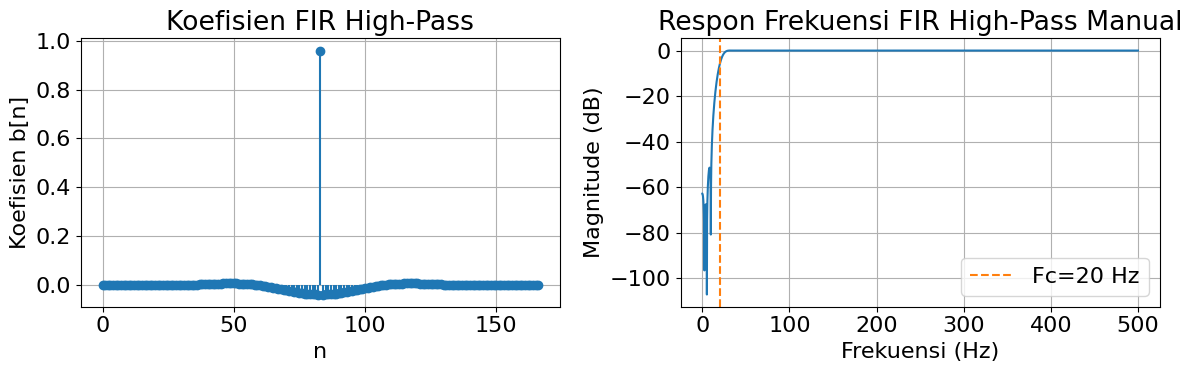

In [19]:
# 1. Buat window function secara manual
if window_type == 'hamming':
    n_window = np.arange(numtaps)
    window = 0.54 - 0.46*np.cos(2*np.pi*n_window/(numtaps-1))
else:
    window = np.ones(numtaps)

# 2. Hitung ideal low-pass impulse response
# Ideal low-pass: h_lp[n] = sin(wc*n) / (pi*n) untuk n != 0, dan wc/pi untuk n = 0
wc = 2 * np.pi * Fc / Fs  # normalized cutoff frequency

h_lp = np.zeros(numtaps)
center = numtaps // 2

for n in range(numtaps):
    n_shift = n - center  # shift agar center di tengah
    if n_shift == 0:
        h_lp[n] = wc / np.pi
    else:
        h_lp[n] = np.sin(wc * n_shift) / (np.pi * n_shift)

# 3. Konversi ke high-pass: h_hp[n] = delta[n] - h_lp[n]
# delta[n] = 1 jika n = center, 0 sebaliknya
h_hp = -h_lp.copy()
h_hp[center] += 1

# 4. Aplikasikan window
b = h_hp * window

print(f"Koefisien FIR High-Pass (numtaps={numtaps}):")
print(f"Center index: {center}")
print(f"Normalized cutoff frequency (wc): {wc:.4f}")
print(f"Jumlah koefisien: {len(b)}")
print(f"Koefisien pertama 10: {b[:10]}")
print(f"Koefisien tengah: {b[center]}")

# Visualisasi koefisien
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(np.arange(numtaps), b, basefmt=' ')
plt.xlabel('n')
plt.ylabel('Koefisien b[n]')
plt.title('Koefisien FIR High-Pass')
plt.grid()

# Respon frekuensi
w, h_freq = signal.freqz(b, worN=4096, fs=Fs)
plt.subplot(1, 2, 2)
plt.plot(
    w,
    20*np.log10(np.maximum(np.abs(h_freq),1e-12))
)
plt.axvline(Fc, linestyle='--', color='C1', label=f'Fc={Fc} Hz')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Respon Frekuensi FIR High-Pass Manual')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

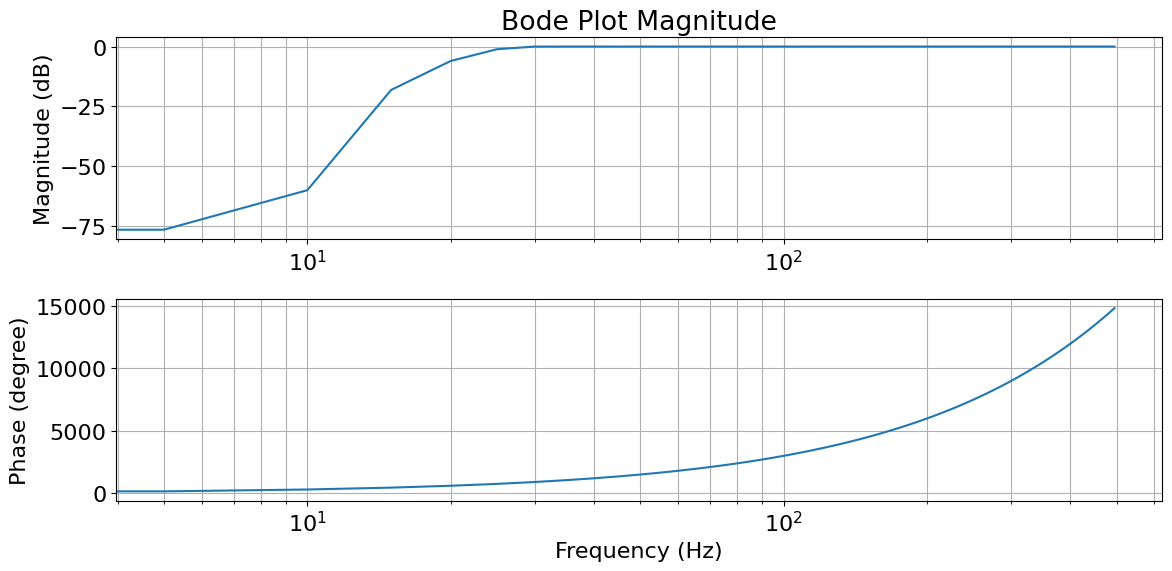

In [20]:
from scipy.signal import dlti, dbode

system = dlti(b, [1], dt=1/Fs)

w, mag, phase = dbode(system)

plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.semilogx(w/(2*np.pi), mag)
plt.title("Bode Plot Magnitude")
plt.ylabel("Magnitude (dB)")
plt.grid(True, which='both')

plt.subplot(2,1,2)
plt.semilogx(w/(2*np.pi), phase)
plt.ylabel("Phase (degree)")
plt.xlabel("Frequency (Hz)")
plt.grid(True, which='both')

plt.tight_layout()
plt.show()

In [21]:
# Bandingkan dengan firwin (hanya untuk referensi)
b_firwin = signal.firwin(numtaps, Fc, fs=Fs, pass_zero=False, window=window_type)
print(f"\nPerbandingan Manual vs Firwin:")
print(f"Max error: {np.max(np.abs(b - b_firwin)):.10f}")
print(f"MSE: {np.mean((b - b_firwin)**2):.10f}")


Perbandingan Manual vs Firwin:
Max error: 0.0002571580
MSE: 0.0000000004


### 5. Aplikasi Filter FIR Manual pada Sinyal EMG

Menggunakan koefisien yang telah dirancang secara manual, kita akan menerapkan filter pada sinyal EMG dengan implementasi sederhana:

$$y_{filtered}[n] = \sum_{i=0}^{N_b-1} b[i] \cdot y[n-i]$$

Dimana:
- $y[n]$ = sinyal input (EMG raw)
- $b[i]$ = koefisien FIR
- $N_b$ = jumlah koefisien
- $y_{filtered}[n]$ = sinyal output yang sudah di-filter


Jumlah koefisien FIR: 167
Ukuran sinyal: 6434
Filtering selesai!
Output shape: (6434,)


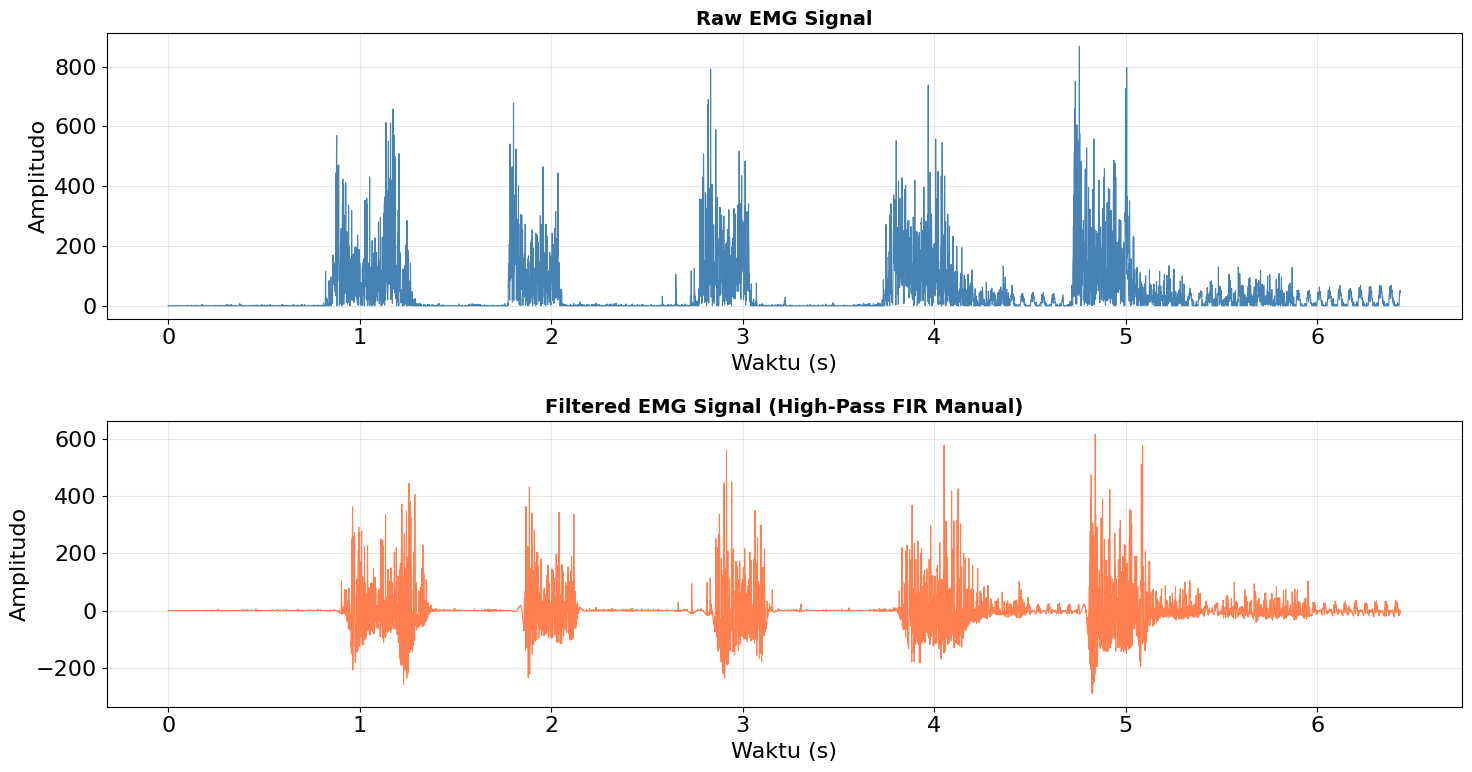

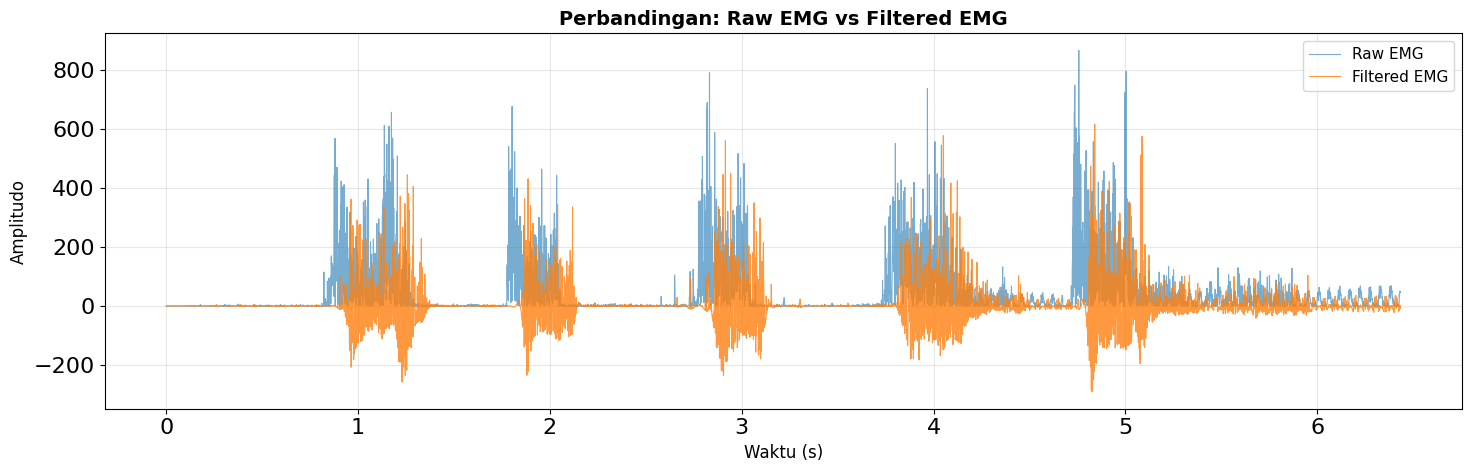

In [22]:
# ===== APLIKASI FILTER FIR MANUAL SEDERHANA =====
# Menggunakan koefisien yang telah dirancang

# Persiapan koefisien
b_filter = np.asarray(b, dtype=float).flatten()
Nb = len(b_filter)
print(f"Jumlah koefisien FIR: {Nb}")
print(f"Ukuran sinyal: {len(y)}")

# ===== FILTERING MANUAL: Y_FILTERED[n] = SUM(b[i] * y[n-i]) =====
y_filtered = np.zeros(len(y), dtype=float)

for n in range(len(y)):
    for i in range(Nb):
        if n - i >= 0:
            y_filtered[n] += b_filter[i] * y[n - i]

print(f"Filtering selesai!")
print(f"Output shape: {y_filtered.shape}")

# ===== PLOT HASIL FILTERING =====
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Plot 1: Sinyal asli
axes[0].plot(t, y, linewidth=0.8, color='steelblue')
axes[0].set_title('Raw EMG Signal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Waktu (s)')
axes[0].set_ylabel('Amplitudo')
axes[0].grid(alpha=0.3)

# Plot 2: Sinyal filtered
axes[1].plot(t, y_filtered, linewidth=0.8, color='coral')
axes[1].set_title('Filtered EMG Signal (High-Pass FIR Manual)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Waktu (s)')
axes[1].set_ylabel('Amplitudo')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Plot overlay perbandingan
plt.figure(figsize=(15, 5))
plt.plot(t, y, label='Raw EMG', alpha=0.6, linewidth=0.8)
plt.plot(t, y_filtered, label='Filtered EMG', alpha=0.8, linewidth=0.8)
plt.xlabel('Waktu (s)', fontsize=12)
plt.ylabel('Amplitudo', fontsize=12)
plt.title('Perbandingan: Raw EMG vs Filtered EMG', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
# VALIDASI DENGAN SCIPY

y_reference = signal.lfilter(b, [1], y)

print("="*60)
print("VALIDASI IMPLEMENTASI")
print("="*60)
print("Maximum Error :", np.max(np.abs(y_filtered-y_reference)))
print("Mean Square Error :", np.mean((y_filtered-y_reference)**2))

VALIDASI IMPLEMENTASI
Maximum Error : 4.547473508864641e-13
Mean Square Error : 7.427016711411326e-28


### 5. Analisis Domain Frekuensi (Spektrum)

Perbandingan spektrum frekuensi sinyal sebelum dan sesudah filtering untuk melihat efektivitas high-pass filter dalam menghilangkan komponen frekuensi rendah.


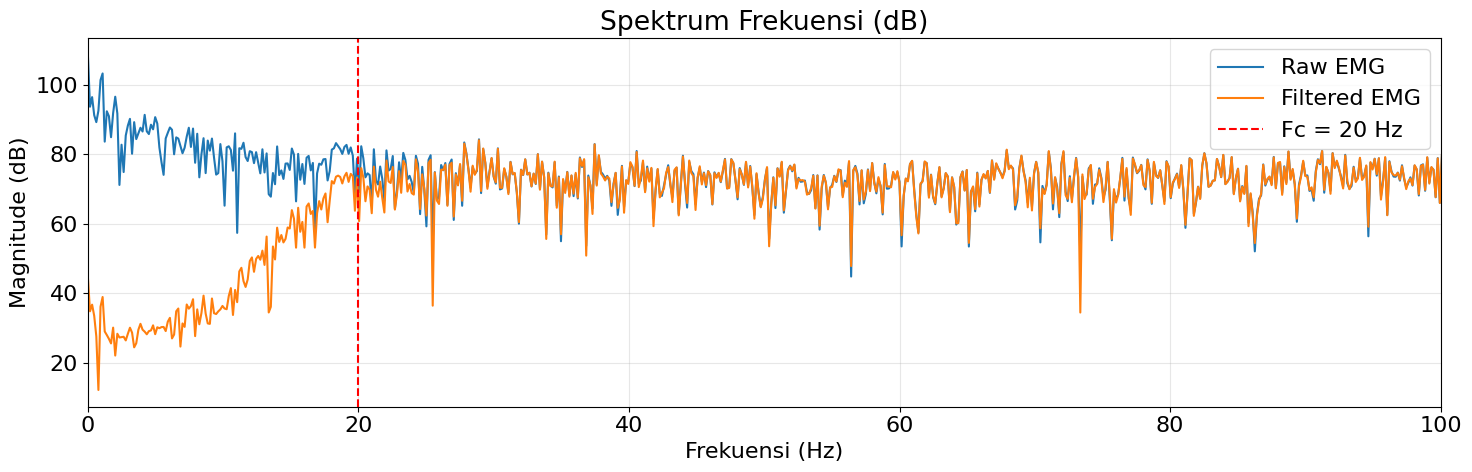

In [24]:
plt.figure(figsize=(15,5))

plt.plot(freq,
         20*np.log10(np.maximum(np.abs(Y_raw),1e-12)),
         label='Raw EMG')

plt.plot(freq,
         20*np.log10(np.maximum(np.abs(Y_filtered),1e-12)),
         label='Filtered EMG')

plt.axvline(Fc,
            color='red',
            linestyle='--',
            label=f'Fc = {Fc} Hz')

plt.xlim(0,100)
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Spektrum Frekuensi (dB)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

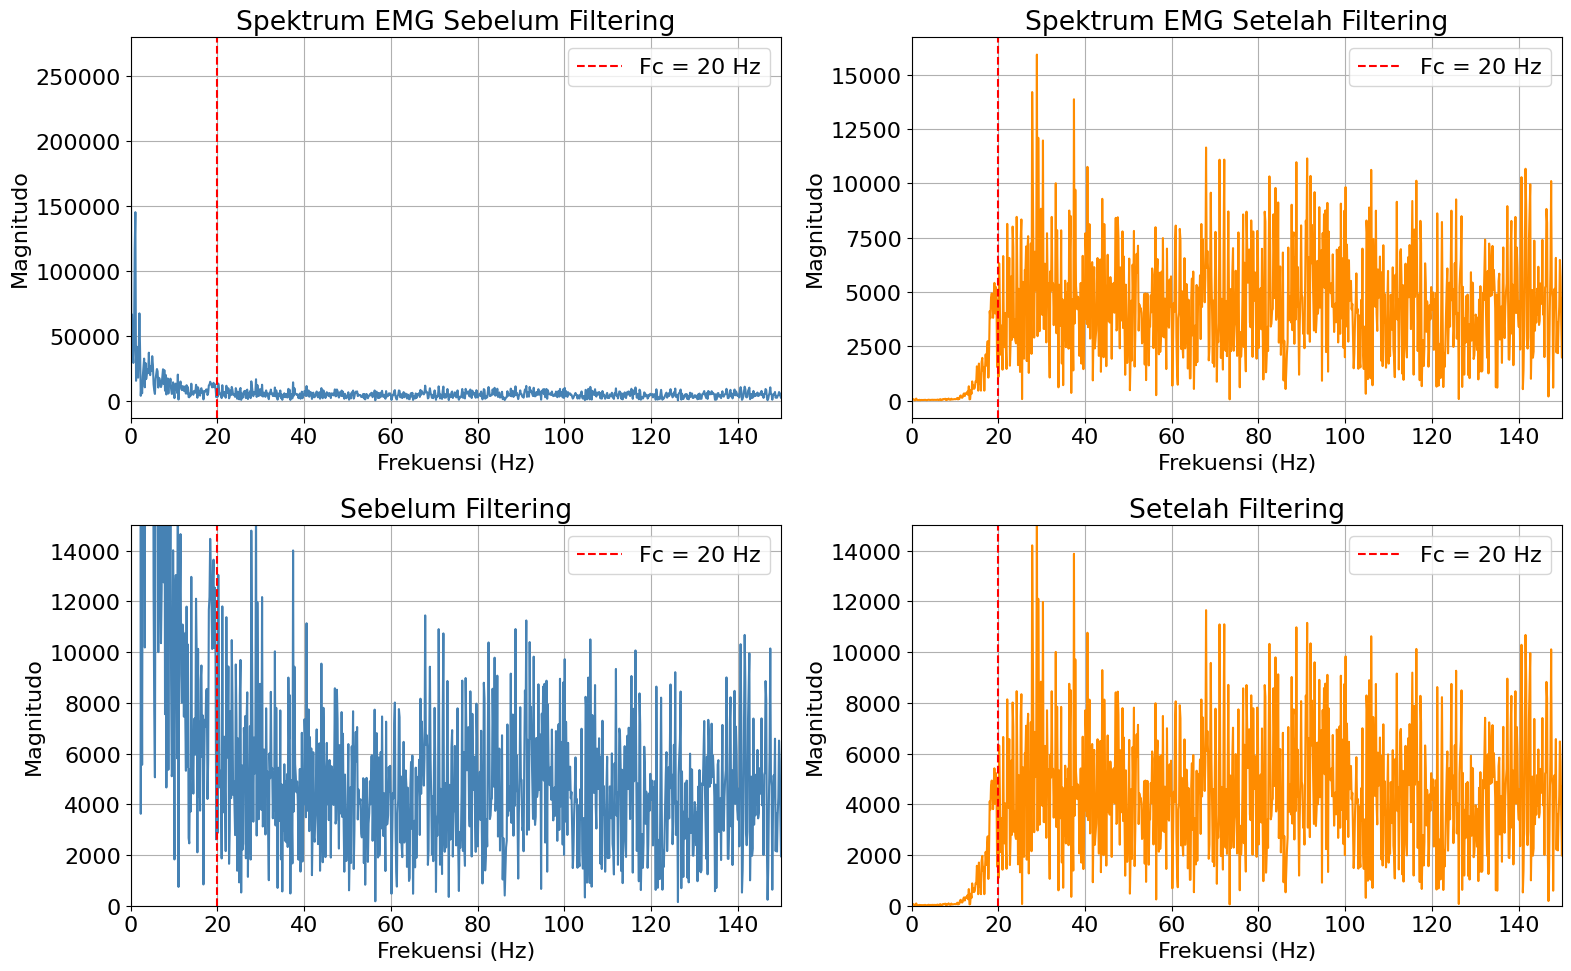

In [25]:
 
# PERBANDINGAN SPEKTRUM FREKUENSI
 

# FFT sinyal asli
Y_raw = np.fft.rfft(y)

# FFT sinyal hasil filtering
Y_filtered = np.fft.rfft(y_filtered)

# Sumbu frekuensi
freq = np.fft.rfftfreq(len(y), d=1/Fs)

 
# Plot Perbandingan
 

fig, ax = plt.subplots(2, 2, figsize=(16,10))

 
# Sebelum Filtering
 
ax[0,0].plot(freq, np.abs(Y_raw), color='steelblue')
ax[0,0].axvline(Fc,linestyle='--',color='red',label=f'Fc = {Fc} Hz')
ax[0,0].set_xlim([0,150])
ax[0,0].set_xlabel("Frekuensi (Hz)")
ax[0,0].set_ylabel("Magnitudo")
ax[0,0].set_title("Spektrum EMG Sebelum Filtering")
ax[0,0].grid(True)
ax[0,0].legend()

 
# Setelah Filtering
 
ax[0,1].plot(freq, np.abs(Y_filtered), color='darkorange')

ax[0,1].axvline(
    Fc,
    linestyle='--',
    color='red',
    label=f'Fc = {Fc} Hz'
)

ax[0,1].set_xlim([0,150])
ax[0,1].set_xlabel("Frekuensi (Hz)")
ax[0,1].set_ylabel("Magnitudo")
ax[0,1].set_title("Spektrum EMG Setelah Filtering")
ax[0,1].grid(True)
ax[0,1].legend()



 
# Sebelum Filtering
 
ax[1,0].plot(freq, np.abs(Y_raw), color='steelblue')
ax[1,0].axvline(Fc,linestyle='--',color='red',label=f'Fc = {Fc} Hz')
ax[1,0].set_xlim([0,150])
ax[1,0].set_ylim([0, 15000])
ax[1,0].set_xlabel("Frekuensi (Hz)")
ax[1,0].set_ylabel("Magnitudo")
ax[1,0].set_title("Sebelum Filtering")
ax[1,0].grid(True)
ax[1,0].legend()

 
# Setelah Filtering
 
ax[1,1].plot(freq, np.abs(Y_filtered), color='darkorange')

ax[1,1].axvline(
    Fc,
    linestyle='--',
    color='red',
    label=f'Fc = {Fc} Hz'
)

ax[1,1].set_xlim([0,150])
ax[1,1].set_ylim([0, 15000])
ax[1,1].set_xlabel("Frekuensi (Hz)")
ax[1,1].set_ylabel("Magnitudo")
ax[1,1].set_title("Setelah Filtering")
ax[1,1].grid(True)
ax[1,1].legend()

plt.tight_layout()
plt.show()